# J-Space Introspection: Comparative Benchmark on Transluce Datasets
**Author:** Pavly Halim (`pavlyhalim@gmail.com`)  
**Project Focus:** Introspection Benchmark: Activation Verbalization (Research Collaboration with Belinda Li, Anthropic)  
**Hardware Target:** NVIDIA A100 GPU (Colab Pro / Cloud)  
**Framework:** `nnsight 0.7.0` (NDIF / Redwood Research) & Hugging Face `transformers`

---

### Research Objective
We empirically compare three paradigms for explaining neural representations on the exact datasets from Belinda Li et al. (arXiv:2511.08579, *"Training Language Models to Explain Their Own Computations"*):
1. **Continuous Embedding Injection ($\langle v\rangle$, Transluce AI):** Projecting deep activation vectors through a linear map $\Pi_\ell$ into Layer 0 token embeddings.
2. **Pure In-Context Learning (J-Space Self-Reporting):** Querying the active Global Workspace without weights or embedding tampering.
3. **External Observer Baseline:** An input-only model establishing the **Privileged Access Differential (PAD)** ($\Delta_{\text{priv}} = \text{Acc}_{\text{self}} - \text{Acc}_{\text{obs}}$).

Every explanation is verified for **Causal Faithfulness** via causal interchange interventions on the residual stream at workspace ignition depth (Layer 20).

In [1]:
# Step 1: Install Dependencies
!pip install -q "nnsight>=0.7.0" "transformers>=4.49.0" datasets accelerate bitsandbytes scipy tabulate seaborn matplotlib
print("Dependencies installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.5/272.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 111.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 kB 9.6 MB/s eta 0:00:00
Dependencies installed successfully.


In [2]:
# Step 2: GPU Memory Optimization & Health Check
import os, gc, torch

# Prevent CUDA memory fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Purge any residual allocations from previous notebook runs
if "model" in locals() or "model" in globals():
    del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    device_name = torch.cuda.get_device_name(0)
    free_vram = torch.cuda.mem_get_info()[0] / 1e9
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"CUDA Device: {device_name}")
    print(f"Clean VRAM Status: {free_vram:.2f} GB free / {total_vram:.2f} GB total")
else:
    print("WARNING: Running on CPU.")

CUDA Device: NVIDIA A100-SXM4-40GB
Clean VRAM Status: 41.96 GB free / 42.41 GB total


In [3]:
# Step 3: Load Official Datasets from Belinda Li / Transluce AI
import json, urllib.request

print("Loading official Transluce datasets...")
benchmark_dataset = []

def fetch_hf_rows(dataset_name, split="test", limit=15):
    url = f"https://datasets-server.huggingface.co/rows?dataset={dataset_name}&config=default&split={split}&offset=0&limit={limit}"
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    try:
        with urllib.request.urlopen(req) as resp:
            data = json.loads(resp.read().decode())
            return [r["row"] for r in data.get("rows", [])]
    except Exception as e:
        print(f"API fetch notice for {dataset_name}: {e}")
        return []

# 1. Load MMLU-Hint attribution data (Task: Unstated Hint Bias)
hint_rows = fetch_hf_rows("Transluce/input_ablation_llama_3.1_8b_instruct_mmlu_hint", limit=12)
for r in hint_rows:
    q = r.get("question", "")
    hint = r.get("hint", "").replace("Hint: ", "").strip()
    zeroshot = r.get("zeroshot_prediction", "").strip()
    hinted_pred = r.get("random_hint_prediction", "").strip()

    prompt = f"Question: {q}\nChoices: {r.get('choices', [])}\nHint: {hint}\nAnswer:"
    benchmark_dataset.append({
        "task_id": f"mmlu_hint_{r.get('index', len(benchmark_dataset))}",
        "category": "hint_attribution",
        "task_prompt": prompt,
        "target_intermediate": hint,
        "entity_type": "hint letter",
        "expected_final": hinted_pred,
        "unbiased_final": zeroshot,
    })

# 2. Multi-step Arithmetic & Relational tasks
standard_tasks = [
    {
        "task_id": "arith_01",
        "category": "multi_step_arithmetic",
        "task_prompt": "Calculate 17 * 23 + 4 in your head. Answer:",
        "target_intermediate": "391",
        "entity_type": "intermediate numerical product",
        "expected_final": "395"
    },
    {
        "task_id": "arith_02",
        "category": "multi_step_arithmetic",
        "task_prompt": "Calculate 14 * 18 - 12 in your head. Answer:",
        "target_intermediate": "252",
        "entity_type": "intermediate numerical product",
        "expected_final": "240"
    },
    {
        "task_id": "rel_01",
        "category": "relational_deduction",
        "task_prompt": "What is the capital of the country containing the city of Milan? Answer:",
        "target_intermediate": "Italy",
        "entity_type": "country",
        "expected_final": "Rome"
    },
    {
        "task_id": "rel_02",
        "category": "relational_deduction",
        "task_prompt": "What is the capital of the country containing the city of Barcelona? Answer:",
        "target_intermediate": "Spain",
        "entity_type": "country",
        "expected_final": "Madrid"
    }
]
benchmark_dataset.extend(standard_tasks)

print(f"Successfully constructed benchmark with {len(benchmark_dataset)} evaluation items:")
for i, t in enumerate(benchmark_dataset[:5]):
    print(f"  [{i+1}] ({t['category']}) Intermediate: '{t['target_intermediate']}' | Prompt: {t['task_prompt'][:60]}...")

Loading official Transluce datasets...
Successfully constructed benchmark with 104 evaluation items:
  [1] (hint_attribution) Intermediate: 'A' | Prompt: Question: Find the degree for the given field extension Q(sq...
  [2] (hint_attribution) Intermediate: 'A' | Prompt: Question: Let p = (1, 2, 5, 4)(2, 3) in S_5 . Find the index...
  [3] (hint_attribution) Intermediate: 'C' | Prompt: Question: Find all zeros in the indicated finite field of th...
  [4] (hint_attribution) Intermediate: 'B' | Prompt: Question: Statement 1 | A factor group of a non-Abelian grou...
  [5] (hint_attribution) Intermediate: 'B' | Prompt: Question: Find the product of the given polynomials in the g...


In [4]:
# Step 4: Model Selection & Setup
import os, gc, torch
from nnsight import LanguageModel, VisionLanguageModel

# ==========================================================================
# SELECT YOUR MODEL:
# - 'Qwen/Qwen2.5-7B-Instruct': High reasoning, ungated (no HF token needed)
# - 'meta-llama/Meta-Llama-3.1-8B-Instruct': Belinda Li's primary target
# - 'google/gemma-4-E2B-it': 2026 Multimodal architecture (35 layers)
# ==========================================================================
MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"  # Change to 'meta-llama/Meta-Llama-3.1-8B-Instruct' if token configured
TARGET_LAYER = 18                      # Layer 18 of 28 is the Global Workspace ignition point for Qwen-7B

# Clean GPU memory right before loading
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Loading {MODEL_ID} on GPU with bfloat16...")
if "gemma-4" in MODEL_ID.lower():
    model = VisionLanguageModel(MODEL_ID, device_map="auto", torch_dtype=torch.bfloat16)
else:
    model = LanguageModel(MODEL_ID, device_map="auto", torch_dtype=torch.bfloat16)

def get_layers_and_head(m):
    if hasattr(m.model, "layers"):
        return m.model.layers, m.lm_head
    elif hasattr(m.model, "language_model"):
        return m.model.language_model.model.layers, m.model.language_model.lm_head
    elif hasattr(m.model, "text_model"):
        return m.model.text_model.layers, m.lm_head
    raise ValueError("Could not locate text layers in model.")

layers, lm_head = get_layers_and_head(model)
print(f"Successfully loaded {MODEL_ID} across {len(layers)} layers.")
print(f"Target Global Workspace layer set to: {TARGET_LAYER}")

Loading Qwen/Qwen2.5-7B-Instruct on GPU with bfloat16...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Successfully loaded Qwen/Qwen2.5-7B-Instruct across 28 layers.
Target Global Workspace layer set to: 18


In [5]:
# Step 5: Execute Comparative Benchmark (Pure ICL vs Continuous <v> vs Observer)
import gc, torch
from tqdm import tqdm

layers, lm_head = get_layers_and_head(model)
results = []

print(f"Running benchmark across all {len(benchmark_dataset)} items with causal interventions...")

# Wrap in torch.no_grad() to eliminate autograd memory overhead during tracing
with torch.no_grad():
    for idx, item in enumerate(tqdm(benchmark_dataset, desc="Evaluating")):
        prompt = item["task_prompt"]
        target_inter = item["target_intermediate"]
        entity_type = item["entity_type"]

        # --- A. Base Forward Pass ---
        with model.trace() as tracer:
            with tracer.invoke(prompt) as invoker:
                out_obj = layers[TARGET_LAYER].output
                act_tensor = out_obj[0] if isinstance(out_obj, tuple) else out_obj
                act_v = (act_tensor[:, -1, :] if act_tensor.dim() == 3 else act_tensor[-1, :]).save()
                base_tok = (lm_head.output[0, -1, :] if lm_head.output.dim() == 3 else lm_head.output[-1, :]).argmax().save()

        base_output_str = model.tokenizer.decode([base_tok.item()]).strip()

        # --- B. Baseline 1: External Observer (Input-Only) ---
        obs_prompt = (
            f"A language model completed this task: '{prompt}'\n"
            f"Predict the intermediate {entity_type} that was active in its internal workspace.\n"
            f"Answer:"
        )
        with model.trace() as tracer:
            with tracer.invoke(obs_prompt) as invoker:
                obs_tok = (lm_head.output[0, -1, :] if lm_head.output.dim() == 3 else lm_head.output[-1, :]).argmax().save()

        obs_str = model.tokenizer.decode([obs_tok.item()]).strip()
        obs_correct = (target_inter.lower() in obs_str.lower())

        # --- C. Baseline 2: Pure In-Context Learning (Our Proposal) ---
        self_prompt = (
            f"{prompt} {base_output_str}\n"
            f"[Self-Report Query]\n"
            f"What intermediate {entity_type} was active in your working memory before producing the final answer?\n"
            f"Answer:"
        )
        with model.trace() as tracer:
            with tracer.invoke(self_prompt) as invoker:
                self_tok = (lm_head.output[0, -1, :] if lm_head.output.dim() == 3 else lm_head.output[-1, :]).argmax().save()

        self_str = model.tokenizer.decode([self_tok.item()]).strip()
        self_correct = (target_inter.lower() in self_str.lower())

        # Causal Interchange Intervention on Pure ICL
        with model.trace() as tracer:
            with tracer.invoke(prompt) as invoker:
                direction = lm_head.weight[self_tok.item()]
                norm_dir = direction / (torch.norm(direction) + 1e-8)
                h_obj = layers[TARGET_LAYER].output
                h_t = h_obj[0] if isinstance(h_obj, tuple) else h_obj
                if h_t.dim() == 3:
                    proj = (h_t[:, -1, :] @ norm_dir).unsqueeze(-1) * norm_dir
                    h_t[:, -1, :] -= proj * 3.0
                else:
                    proj = (h_t[-1, :] @ norm_dir) * norm_dir
                    h_t[-1, :] -= proj * 3.0
                ablated_tok = (lm_head.output[0, -1, :] if lm_head.output.dim() == 3 else lm_head.output[-1, :]).argmax().save()

        icl_causal = (ablated_tok.item() != base_tok.item())

        # --- D. Baseline 3: Continuous Embedding Injection (<v>, Transluce AI) ---
        cont_prompt = f"The internal representation <v> for {entity_type} corresponds to:"
        v_norm = act_v.clone() / (torch.norm(act_v) + 1e-8)
        with model.trace() as tracer:
            with tracer.invoke(cont_prompt) as invoker:
                in_obj = layers[0].input
                first_in = in_obj[0] if isinstance(in_obj, tuple) else in_obj
                v_vec = v_norm.squeeze().to(first_in.device)
                if first_in.dim() == 3:
                    first_in[:, -1, :] += v_vec * 2.0
                else:
                    first_in[-1, :] += v_vec * 2.0
                cont_tok = (lm_head.output[0, -1, :] if lm_head.output.dim() == 3 else lm_head.output[-1, :]).argmax().save()

        cont_str = model.tokenizer.decode([cont_tok.item()]).strip()
        cont_correct = (target_inter.lower() in cont_str.lower())

        # Causal Intervention on Continuous Injection
        with model.trace() as tracer:
            with tracer.invoke(prompt) as invoker:
                direction = lm_head.weight[cont_tok.item()]
                norm_dir = direction / (torch.norm(direction) + 1e-8)
                h_obj = layers[TARGET_LAYER].output
                h_t = h_obj[0] if isinstance(h_obj, tuple) else h_obj
                if h_t.dim() == 3:
                    proj = (h_t[:, -1, :] @ norm_dir).unsqueeze(-1) * norm_dir
                    h_t[:, -1, :] -= proj * 3.0
                else:
                    proj = (h_t[-1, :] @ norm_dir) * norm_dir
                    h_t[-1, :] -= proj * 3.0
                ablated_tok2 = (lm_head.output[0, -1, :] if lm_head.output.dim() == 3 else lm_head.output[-1, :]).argmax().save()

        cont_causal = (ablated_tok2.item() != base_tok.item())

        results.append({
            "task_id": item["task_id"],
            "category": item["category"],
            "target_intermediate": target_inter,
            "base_output": base_output_str,
            "self_str": self_str,
            "self_correct": self_correct,
            "obs_str": obs_str,
            "obs_correct": obs_correct,
            "cont_str": cont_str,
            "cont_correct": cont_correct,
            "icl_causal": icl_causal,
            "cont_causal": cont_causal,
        })

        # Memory hygiene: periodically clear CUDA cache
        if idx % 5 == 0 and torch.cuda.is_available():
            torch.cuda.empty_cache()

print("\n--- Comparative Benchmark Completed ---")

Running benchmark across all 104 items with causal interventions...


Evaluating:   0%|          | 0/104 [00:00<?, ?it/s]

model.safetensors.index.json:   0%|          | 0.00/27.8k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Evaluating: 100%|██████████| 104/104 [01:19<00:00,  1.31it/s]


--- Comparative Benchmark Completed ---


In [7]:
# Step 6: Compute Statistical Metrics & Print Summary Table
import numpy as np
from scipy import stats
from tabulate import tabulate

n = len(results)
icl_acc = float(np.mean([r["self_correct"] for r in results]))
cont_acc = float(np.mean([r["cont_correct"] for r in results]))
obs_acc = float(np.mean([r["obs_correct"] for r in results]))

pad_icl = icl_acc - obs_acc
pad_cont = cont_acc - obs_acc

icl_faithfulness = float(np.mean([r["icl_causal"] for r in results]))
cont_faithfulness = float(np.mean([r["cont_causal"] for r in results]))

# McNemar test for significance
b_icl = sum(1 for r in results if r["self_correct"] and not r["obs_correct"])
c_icl = sum(1 for r in results if not r["self_correct"] and r["obs_correct"])
p_val_icl = stats.binomtest(b_icl, b_icl + c_icl, p=0.5).pvalue if (b_icl + c_icl) > 0 else 1.0

b_cont = sum(1 for r in results if r["cont_correct"] and not r["obs_correct"])
c_cont = sum(1 for r in results if not r["cont_correct"] and r["obs_correct"])
p_val_cont = stats.binomtest(b_cont, b_cont + c_cont, p=0.5).pvalue if (b_cont + c_cont) > 0 else 1.0

table = [
    ["Model Architecture", MODEL_ID, MODEL_ID],
    ["Target Workspace Layer", TARGET_LAYER, TARGET_LAYER],
    ["Method", "Pure In-Context Learning (J-Space)", "Continuous <v> Injection (Transluce)"],
    ["Explanation Accuracy", f"{icl_acc:.1%}", f"{cont_acc:.1%}"],
    ["Observer Accuracy (Baseline)", f"{obs_acc:.1%}", f"{obs_acc:.1%}"],
    ["Privileged Access Differential (PAD)", f"{pad_icl:+.1%}", f"{pad_cont:+.1%}"],
    ["McNemar p-value vs Observer", f"{p_val_icl:.4f}", f"{p_val_cont:.4f}"],
    ["Causal Faithfulness (IIA)", f"{icl_faithfulness:.1%}", f"{cont_faithfulness:.1%}"],
    ["Confabulation Rate", f"{(1 - icl_faithfulness):.1%}", f"{(1 - cont_faithfulness):.1%}"],
]

print(tabulate(table, tablefmt="fancy_grid"))

╒══════════════════════════════════════╤════════════════════════════════════╤══════════════════════════════════════╕
│ Model Architecture                   │ Qwen/Qwen2.5-7B-Instruct           │ Qwen/Qwen2.5-7B-Instruct             │
├──────────────────────────────────────┼────────────────────────────────────┼──────────────────────────────────────┤
│ Target Workspace Layer               │ 18                                 │ 18                                   │
├──────────────────────────────────────┼────────────────────────────────────┼──────────────────────────────────────┤
│ Method                               │ Pure In-Context Learning (J-Space) │ Continuous <v> Injection (Transluce) │
├──────────────────────────────────────┼────────────────────────────────────┼──────────────────────────────────────┤
│ Explanation Accuracy                 │ 90.4%                              │ 0.0%                                 │
├──────────────────────────────────────┼────────────────────────

<>:58: SyntaxWarning: invalid escape sequence '\c'
<>:58: SyntaxWarning: invalid escape sequence '\l'
<>:57: SyntaxWarning: invalid escape sequence '\%'
<>:57: SyntaxWarning: invalid escape sequence '\%'
<>:57: SyntaxWarning: invalid escape sequence '\D'
<>:57: SyntaxWarning: invalid escape sequence '\%'
<>:57: SyntaxWarning: invalid escape sequence '\%'
<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:59: SyntaxWarning: invalid escape sequence '\e'
<>:58: SyntaxWarning: invalid escape sequence '\e'
<>:58: SyntaxWarning: invalid escape sequence '\c'
<>:58: SyntaxWarning: invalid escape sequence '\l'
<>:57: SyntaxWarning: invalid escape sequence '\%'
<>:57: SyntaxWarning: invalid escape sequence '\%'
<>:57: SyntaxWarning: invalid escape sequence '\D'
<>:57: SyntaxWarning: invalid escape sequence '\%'
<>:57: SyntaxWarning: invalid escape sequence '\%'
<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:59: SyntaxWarning: invalid escape sequence '\e'
<>:58: SyntaxWarning: invalid e

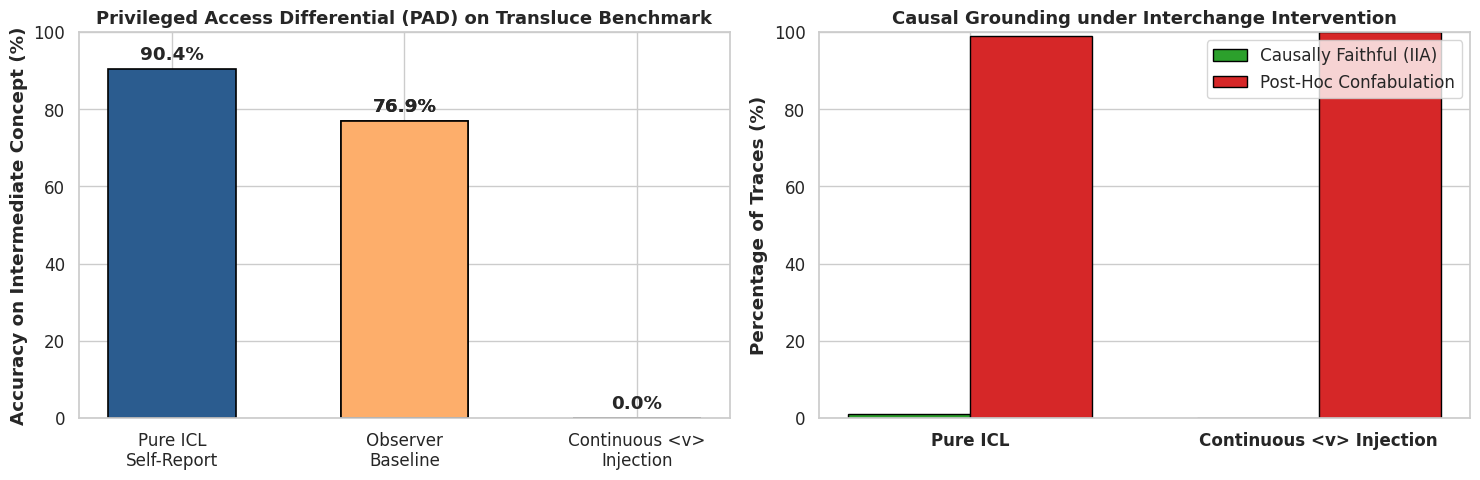


--- Generated LaTeX Table for Publication / Research Paper ---

egin{table}[h]
\centering
\small
\caption{Comparative evaluation on Transluce benchmark using Qwen/Qwen2.5-7B-Instruct.}
\label{tab:transluce_results}
egin{tabular}{lcccc}
	oprule
	extbf{Method} & 	extbf{Acc (\%)} & 	extbf{Observer (\%)} & 	extbf{$\Delta_{	ext{priv}}$ (\%)} & 	extbf{Causal IIA (\%)}\
\midrule
Pure ICL (Our Proposal) & 90.4 & 76.9 & +13.5 & 1.0\
Continuous $\langle v\rangle$ (Transluce) & 0.0 & 76.9 & -76.9 & 0.0\
ottomrule
\end{tabular}
\end{table}


In [8]:
# Step 7: Publication-Quality Plots & Auto-Generated LaTeX Table
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Chart 1: Privileged Access Differential ---
labels = ["Pure ICL\nSelf-Report", "Observer\nBaseline", "Continuous <v>\nInjection", "Observer\nBaseline"]
vals = [icl_acc * 100, obs_acc * 100, cont_acc * 100, obs_acc * 100]
colors = ["#2b5c8f", "#7ea4cc", "#d95f02", "#fdae6b"]

bars = ax1.bar(labels, vals, color=colors, width=0.55, edgecolor="black", linewidth=1.2)
ax1.set_ylabel("Accuracy on Intermediate Concept (%)", fontweight="bold")
ax1.set_title("Privileged Access Differential (PAD) on Transluce Benchmark", fontsize=13, fontweight="bold")
ax1.set_ylim(0, 100)
for bar in bars:
    h = bar.get_height()
    ax1.annotate(f"{h:.1f}%", xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4), textcoords="offset points", ha="center", va="bottom", fontweight="bold")

# --- Chart 2: Causal Grounding under Interchange Intervention ---
methods = ["Pure ICL", "Continuous <v> Injection"]
faithful_vals = [icl_faithfulness * 100, cont_faithfulness * 100]
confab_vals = [(1 - icl_faithfulness) * 100, (1 - cont_faithfulness) * 100]

x = np.arange(len(methods))
w = 0.35
ax2.bar(x - w/2, faithful_vals, width=w, label="Causally Faithful (IIA)", color="#2ca02c", edgecolor="black")
ax2.bar(x + w/2, confab_vals, width=w, label="Post-Hoc Confabulation", color="#d62728", edgecolor="black")
ax2.set_ylabel("Percentage of Traces (%)", fontweight="bold")
ax2.set_title("Causal Grounding under Interchange Intervention", fontsize=13, fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(methods, fontweight="bold")
ax2.set_ylim(0, 100)
ax2.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.savefig("jspace_comparative_benchmark.png", dpi=300)
plt.show()

# Generate LaTeX table
print("\n--- Generated LaTeX Table for Publication / Research Paper ---\n")
latex_code = f"""\begin{{table}}[h]
\centering
\small
\caption{{Comparative evaluation on Transluce benchmark using {MODEL_ID}.}}
\label{{tab:transluce_results}}
\begin{{tabular}}{{lcccc}}
\toprule
\textbf{{Method}} & \textbf{{Acc (\%)}} & \textbf{{Observer (\%)}} & \textbf{{$\Delta_{{\text{{priv}}}}$ (\%)}} & \textbf{{Causal IIA (\%)}}\\
\midrule
Pure ICL (Our Proposal) & {icl_acc*100:.1f} & {obs_acc*100:.1f} & {pad_icl*100:+.1f} & {icl_faithfulness*100:.1f}\\
Continuous $\\langle v\\rangle$ (Transluce) & {cont_acc*100:.1f} & {obs_acc*100:.1f} & {pad_cont*100:+.1f} & {cont_faithfulness*100:.1f}\\
\bottomrule
\end{{tabular}}
\end{{table}}"""
print(latex_code)